
# Momentum QIS — Baseline Notebook

**Goal:** Implement baseline momentum strategies (cross-sectional *and* time-series), build a rules-based synthetic index with volatility targeting and transaction costs, and benchmark against simple references.



## Table of contents
1. Setup & imports  
2. Data (yfinance)  
3. Signals: Cross-Sectional Momentum (12–1) & Time-Series Momentum (sign of 12M)  
4. Portfolio construction (deciles, vol targeting, costs)  
5. Backtest engine  
6. Performance & plots  
7. Optional factor regression hooks  
8. Extensions


## 1) Setup & imports

In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple

import yfinance as yf  
from tqdm import tqdm

import statsmodels.api as sm
from sklearn.linear_model import LassoCV


## 2) Data download & preprocessing

In [2]:

START = "2005-01-01"
END = None  # to today
FREQ = "M"  # monthly signals / rebal

# Simple US large-cap universe (you can of course replace with your own / index members, this is an exemple)
UNIVERSE = [
    "AAPL","MSFT","AMZN","NVDA","META","GOOGL","GOOG","BRK-B","XOM","JNJ","JPM","V",
    "PG","LLY","AVGO","TSM","UNH","MA","HD","CVX","MRK","ABBV","KO","PEP","BAC",
    "WMT","ADBE","ORCL","COST","ASML","TMO","CSCO","TM","ACN","MCD","DHR","NFLX",
    "LIN","AZN","INTC","NKE","TXN","AMD","PM","UPS","HON","RY","SHEL"
]

prices_d = yf.download(UNIVERSE, start=START, end=END, auto_adjust=True, progress=False)["Close"]
prices_m = prices_d.resample(FREQ).last().dropna(how="all")
prices_m = prices_m.dropna(axis=1, how="any")
returns_m = prices_m.pct_change().fillna(0.0)

print("Monthly prices shape:", prices_m.shape)
prices_m.tail()


Monthly prices shape: (251, 42)


Ticker,AAPL,ACN,ADBE,AMD,AMZN,ASML,AZN,BAC,BRK-B,COST,...,RY,SHEL,TM,TMO,TSM,TXN,UNH,UPS,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,207.133911,267.100006,357.690002,176.309998,234.110001,693.479675,72.585220,47.008530,471.880005,937.014404,...,128.460007,71.498238,178.970001,467.260559,240.860138,179.458191,247.995422,84.563004,97.751694,110.610725
2025-08-31,231.915176,259.970001,356.700012,162.630005,229.000000,741.304810,79.900002,50.459335,502.980011,941.987305,...,145.360001,73.879997,194.570007,492.278107,230.143936,200.688690,307.927307,87.440002,96.980003,114.290001
2025-09-30,254.383408,246.600006,352.750000,161.789993,219.570007,966.375488,76.720001,51.590000,502.739990,924.322327,...,147.320007,71.529999,191.089996,485.019989,279.290009,182.104568,345.299988,83.529999,103.059998,112.750000
2025-10-31,270.108154,250.100006,340.309998,256.119995,244.220001,1059.229980,82.400002,53.450001,477.540009,911.450012,...,146.500000,74.919998,204.190002,567.390015,300.429993,161.460007,341.559998,96.419998,101.180000,114.360001
2025-11-30,269.429993,244.550003,328.850006,243.979996,248.399994,1038.790039,87.480003,53.419998,496.980011,915.559998,...,146.889999,76.559998,203.940002,576.349976,295.269989,160.580002,321.579987,93.059998,102.419998,118.220001


## 3) Signals

### 3.1 Cross-Sectional Momentum — 12–1 lookback

In [3]:

def cs_momentum_signal(prices: pd.DataFrame, lb_months: int = 12, skip_months: int = 1) -> pd.DataFrame:
    # Cross-sectional momentum: past lb-month return excluding last skip_months.
    ret = prices.pct_change().fillna(0)
    roll = (1 + ret).rolling(lb_months).apply(np.prod, raw=True) - 1
    return roll.shift(skip_months)

sig_csmom = cs_momentum_signal(prices_m, lb_months=12, skip_months=1)
sig_csmom.tail()


Ticker,AAPL,ACN,ADBE,AMD,AMZN,ASML,AZN,BAC,BRK-B,COST,...,RY,SHEL,TM,TMO,TSM,TXN,UNH,UPS,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,-0.021320,0.002619,-0.303596,-0.125208,0.135265,-0.209041,-0.085603,0.219002,0.194125,0.170670,...,0.280839,0.016635,-0.130673,-0.264406,0.321981,0.098600,-0.375838,-0.220377,0.458930,-0.030934
2025-08-31,-0.060966,-0.177254,-0.351600,0.220307,0.252059,-0.250847,-0.057617,0.201401,0.076123,0.147391,...,0.189683,0.027816,-0.043519,-0.234997,0.478424,-0.084910,-0.558678,-0.301455,0.442106,-0.025779
2025-09-30,0.018430,-0.225750,-0.379015,0.094709,0.282913,-0.170096,-0.068650,0.275669,0.056858,0.062508,...,0.245437,0.074971,0.060398,-0.196305,0.364106,-0.026926,-0.465061,-0.276672,0.267974,0.004090
2025-10-31,0.097919,-0.289525,-0.318726,-0.013957,0.178393,0.173567,0.005737,0.330748,0.092296,0.049474,...,0.222258,0.130890,0.091178,-0.213135,0.630607,-0.083822,-0.396612,-0.348497,0.288729,-0.003355
2025-11-30,0.202374,-0.264339,-0.288174,0.777747,0.310193,0.589996,0.182828,0.308175,0.059035,0.049467,...,0.243784,0.156430,0.203384,0.042231,0.598733,-0.179454,-0.381811,-0.235170,0.246694,0.014685


### 3.2 Time-Series Momentum — sign of past 12M return (skip last month)

In [4]:

def ts_momentum_signal(prices: pd.DataFrame, lb_months: int = 12, skip_months: int = 1) -> pd.DataFrame:
    # Time-series momentum: position per asset is sign of its own past return.
    ret = prices.pct_change().fillna(0)
    roll = (1 + ret).rolling(lb_months).apply(np.prod, raw=True) - 1
    s = np.sign(roll.shift(skip_months))
    return s.replace({np.nan: 0})

sig_tsmom = ts_momentum_signal(prices_m, lb_months=12, skip_months=1)
sig_tsmom.tail()


Ticker,AAPL,ACN,ADBE,AMD,AMZN,ASML,AZN,BAC,BRK-B,COST,...,RY,SHEL,TM,TMO,TSM,TXN,UNH,UPS,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,-1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,...,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0
2025-08-31,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,...,1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-09-30,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0
2025-10-31,1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-11-30,1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0


## 4) Portfolio construction

In [5]:

@dataclass
class QISConfig:
    target_vol_annual: float = 0.10  # 10%
    vol_window: int = 12             # months
    tc_bps: float = 10.0             # round-trip transaction cost (bps)
    long_frac: float = 0.1           # top decile
    short_frac: float = 0.1          # bottom decile
    max_leverage: float = 3.0

def vol_target_scaler(ret_m: pd.Series, window: int, target_vol_annual: float) -> pd.Series:
    vol = ret_m.rolling(window).std()
    vol_annual = vol * np.sqrt(12.0)
    scaler = (target_vol_annual / vol_annual).clip(upper=50).fillna(0.0)
    return scaler

def long_short_weights_from_signal(signal: pd.DataFrame, long_frac: float, short_frac: float) -> pd.DataFrame:
    # Rank signal cross-sectionally; long top quantile, short bottom quantile, equal weights.
    w = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    ranks = signal.rank(axis=1, method="first", ascending=False)  # high = strong momentum
    n = signal.shape[1]
    k_long = max(1, int(np.floor(n * long_frac)))
    k_short = max(1, int(np.floor(n * short_frac)))
    for t in signal.index:
        r = ranks.loc[t]
        long_idx = r.nsmallest(k_long).index
        short_idx = r.nlargest(k_short).index
        w.loc[t, long_idx] = 1.0 / k_long
        w.loc[t, short_idx] = -1.0 / k_short
    return w

def timeseries_weights_from_signal(signal_ts: pd.DataFrame) -> pd.DataFrame:
    # Equal-weight assets by their own sign; normalize absolute weights to 1.
    w = signal_ts.copy().fillna(0.0)
    abs_sum = w.abs().sum(axis=1).replace(0, np.nan)
    w = w.div(abs_sum, axis=0).fillna(0.0)
    return w

def apply_transaction_costs(weights: pd.DataFrame, tc_bps: float) -> pd.Series:
    # Approximate monthly turnover cost: sum |Δw_i| * tc, applied at rebal dates.
    dw = weights.diff().abs().sum(axis=1).fillna(0.0)
    tc = dw * (tc_bps / 10000.0)
    return tc

def backtest(prices: pd.DataFrame, weights: pd.DataFrame, cfg: QISConfig):
    rets = prices.pct_change().fillna(0.0)
    port_ret_gross = (weights.shift(1) * rets).sum(axis=1)  # next-month return from end-of-month weights
    scaler = vol_target_scaler(port_ret_gross, cfg.vol_window, cfg.target_vol_annual).clip(upper=cfg.max_leverage)
    port_ret_scaled = port_ret_gross * scaler
    tc = apply_transaction_costs(weights, cfg.tc_bps)
    port_ret_net = port_ret_scaled - tc
    equity = (1 + port_ret_net).cumprod()
    return port_ret_net, equity


## 5) Run strategies

In [6]:

cfg = QISConfig(target_vol_annual=0.10, vol_window=12, tc_bps=10.0, long_frac=0.1, short_frac=0.1)

# Cross-Sectional Momentum weights
w_cs = long_short_weights_from_signal(sig_csmom, cfg.long_frac, cfg.short_frac)
ret_cs, eq_cs = backtest(prices_m, w_cs, cfg)

# Time-Series Momentum weights
w_ts = timeseries_weights_from_signal(sig_tsmom)
ret_ts, eq_ts = backtest(prices_m, w_ts, cfg)

# Benchmark: SPY 
try:
    spy = yf.download("SPY", start=START, end=END, auto_adjust=True, progress=False)["Close"].resample("M").last()
    ret_spy = spy.pct_change().fillna(0.0)
    eq_spy = (1 + ret_spy).cumprod()
except Exception as e:
    print("Benchmark SPY unavailable in this environment. Run locally to fetch.")
    ret_spy = None
    eq_spy = None

eq_cs.name = "CSMOM"
eq_ts.name = "TSMOM"


## 6) Performance & plots

,Ann.Return,Ann.Vol,Sharpe,MaxDD
CSMOM,-0.007,0.100,-0.074,-0.290
TSMOM,0.096,0.103,0.932,-0.199


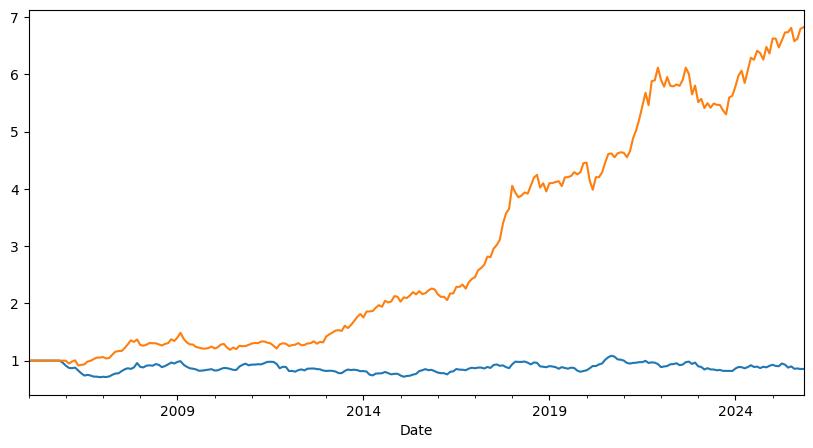

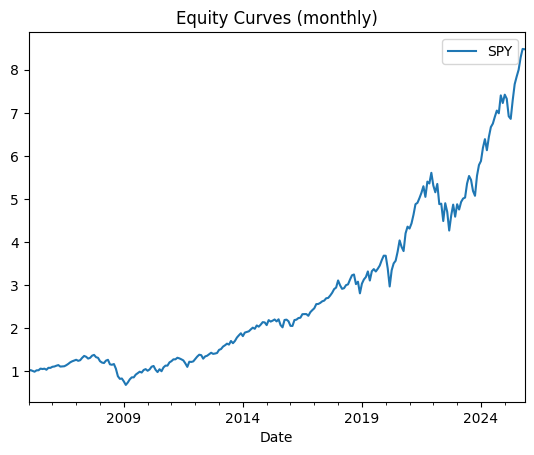

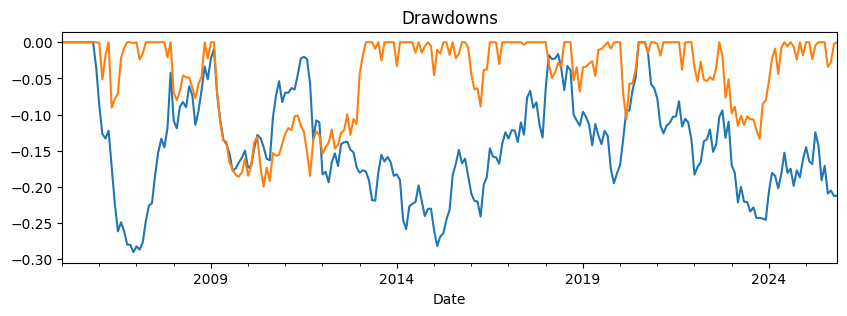

In [8]:

def perf_stats(ret: pd.Series, rf: float = 0.0) -> dict:
    if len(ret) == 0:
        return {}
    ann_ret = (1 + ret).prod() ** (12 / max(1, len(ret))) - 1
    ann_vol = ret.std() * np.sqrt(12)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan
    dd = (1 + ret).cumprod() / ((1 + ret).cumprod().cummax()) - 1
    max_dd = dd.min()
    return {"Ann.Return": ann_ret, "Ann.Vol": ann_vol, "Sharpe": sharpe, "MaxDD": max_dd}

stats = pd.DataFrame({
    "CSMOM": perf_stats(ret_cs),
    "TSMOM": perf_stats(ret_ts),
}).T
display(stats.round(3))

plt.figure(figsize=(10,5))
(1+ret_cs).cumprod().rename("CSMOM").plot()
(1+ret_ts).cumprod().rename("TSMOM").plot()
if 'eq_spy' in locals() and eq_spy is not None:
    eq_spy = eq_spy.copy()
    eq_spy.name = "SPY"
    eq_spy.plot()
plt.title("Equity Curves (monthly)")
plt.legend()
plt.show()

plt.figure(figsize=(10,3))
dd_cs = (1+ret_cs).cumprod() / ((1+ret_cs).cumprod().cummax()) - 1
dd_ts = (1+ret_ts).cumprod() / ((1+ret_ts).cumprod().cummax()) - 1
dd_cs.rename("CSMOM").plot()
dd_ts.rename("TSMOM").plot()
plt.title("Drawdowns")
plt.show()


## 8) Export & next steps

In [ ]:

out = pd.DataFrame({"ret_csmom": ret_cs, "ret_tsmom": ret_ts}).dropna()
out.to_csv("momentum_qis_monthly_returns.csv")
print("Saved: momentum_qis_monthly_returns.csv")
